# Lab 04 — torch.Tensor เทียบ numpy.ndarray ทีละบรรทัด
### torch.Tensor vs numpy.ndarray side by side, and autograd

**กลุ่ม:** A พื้นฐาน · **อ่านคู่กับสไลด์หน้า:** 10-12, 22-24 · **เวลาโดยประมาณ:** 75 นาที · **Dataset:** ไม่ใช้

**ควรทำมาก่อน:** Lab 01 (shape, axis, broadcasting), Lab 02 (nudge, chain rule)

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. สร้าง `torch.Tensor` แล้วอ่าน `shape` / `dtype` / `device` ได้ และแปลงไปมากับ `numpy.ndarray` โดยรู้ว่าตอนไหน copy ตอนไหนใช้หน่วยความจำร่วมกัน
2. อธิบายได้ว่าทำไม torch ใช้ float32 เป็นค่าเริ่มต้นขณะที่ numpy ใช้ float64 และแก้ error จาก dtype ไม่ตรงกันได้
3. เขียน reshape / view / transpose / matmul / broadcasting / sum ด้วย torch ให้ได้ผลเท่ากับ numpy ทุกบรรทัด (ตรวจด้วย `np.allclose`)
4. ใช้ autograd (`requires_grad`, `backward()`, `.grad`) หา $dJ/da, dJ/db, dJ/dc$ ของ $J = 3(a + bc)$ ได้ 3, 6, 9 ตรงกับ chain rule ใน lab02 และตรวจอนุพันธ์ของ sigmoid / tanh / ReLU (สไลด์ p.10-12)
5. รู้ว่า `.grad` สะสมทุกครั้งที่เรียก `backward()` จึงต้องล้างเป็นศูนย์ก่อนรอบถัดไป และใช้ `torch.no_grad()` เมื่อไม่ต้องการ gradient

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)
lab นี้เพิ่ม `import torch` และ `torch.manual_seed(463)` — ตัวสุ่มของ torch แยกจาก numpy จึงต้องตั้ง seed แยก (จริงๆ `set_seed` ของ nnlab ทำให้แล้ว แต่เขียนซ้ำให้เห็นชัด)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed
import torch
torch.manual_seed(463)
rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์ในบทนี้
| สัญลักษณ์ | ความหมาย | ใน torch |
|---|---|---|
| tensor | array หลายมิติแบบเดียวกับ `ndarray` แต่รู้จัก autograd และ GPU | `torch.Tensor` |
| `dtype` | ชนิดตัวเลข — torch ใช้ `float32` เป็นค่าเริ่มต้น numpy ใช้ `float64` | `t.dtype`, `t.float()`, `t.double()` |
| `device` | หน่วยความจำที่ tensor อยู่: `cpu`, `mps` (Apple GPU), `cuda` (NVIDIA GPU) | `t.device`, `t.to(device)` |
| `requires_grad` | บอก torch ให้ "จด" ทุกการคำนวณที่ทำกับ tensor นี้เพื่อหาอนุพันธ์ทีหลัง | `torch.tensor(5.0, requires_grad=True)` |
| $\dfrac{dJ}{da}$ | อนุพันธ์ของ $J$ เทียบ $a$ ที่ autograd คำนวณให้ (p.22-24) | `J.backward()` แล้วอ่าน `a.grad` |

## ขั้นที่ 1 · ทำไมต้องมี torch ในเมื่อมี numpy แล้ว
numpy ทำได้ทุกอย่างที่เราใช้ใน lab01-03 แต่ขาดสองสิ่งที่ neural network ขนาดใหญ่ต้องการ
1. **autograd** — หาอนุพันธ์ของ function ซ้อนกันหลายชั้นให้อัตโนมัติ (lab02 เราเดิน chain rule เอง; กับ network 50 ชั้นทำมือไม่ไหว)
2. **GPU** — ย้ายการคูณ matrix ไปทำบนการ์ดจอที่คูณได้ทีละหลายพันตัวพร้อมกัน

`torch.Tensor` คือ `ndarray` ที่เพิ่มสองความสามารถนี้เข้าไป ส่วนที่เหลือ **เกือบทุกคำสั่งชื่อเดียวกัน** ตารางนี้คือแผนที่ที่จะใช้ตลอด lab

| งาน | numpy | torch |
|---|---|---|
| สร้างจาก list | `np.array([...])` | `torch.tensor([...])` |
| ศูนย์ / หนึ่ง / ลำดับ | `np.zeros`, `np.ones`, `np.arange` | `torch.zeros`, `torch.ones`, `torch.arange` |
| สุ่ม | `rng.standard_normal(shape)` | `torch.randn(shape)` |
| อ่าน shape | `.shape` (tuple) | `.shape` (`torch.Size` ใช้เหมือน tuple) |
| เปลี่ยนรูป | `.reshape` | `.reshape` หรือ `.view` |
| transpose | `.T` | `.T` |
| matrix multiplication | `@` | `@` |
| รวมตามแกน | `.sum(axis=0)` | `.sum(dim=0)` |
| คงมิติไว้ | `keepdims=True` | `keepdim=True` |
| exp / sigmoid | `np.exp`, เขียนเอง | `torch.exp`, `torch.sigmoid` |
| เปลี่ยน dtype | `.astype(np.float32)` | `.to(torch.float32)` หรือ `.float()` |
| numpy ↔ torch | — | `torch.from_numpy(a)`, `t.numpy()` |
| เทียบค่า | `np.allclose` | `torch.allclose` (หรือแปลงเป็น numpy ก่อน) |

ทั้ง lab เราจะทำงานเดียวกัน **สอง cell ติดกัน**: cell แรก numpy (ที่รู้จักแล้ว) cell ถัดไป torch แล้วเทียบด้วย `np.allclose` ทุกครั้ง

### คู่ที่ 1 · สร้าง array และอ่าน shape / dtype
**numpy** — สร้าง matrix 2×3 จาก list, สร้าง zeros/ones/arange และสุ่มด้วย `rng` เหมือน lab01
สังเกต `dtype` ของ `np.array([1., 2., 3.])` คือ `float64`

In [2]:
# ---- numpy ----
A_np = np.array([[1., 2., 3.],
                 [4., 5., 6.]])                      # A_np: (2, 3)
print("A_np:\n", A_np)
print("shape", A_np.shape, "| dtype", A_np.dtype, "| ndim", A_np.ndim)
print("zeros", np.zeros((2, 2)).shape, "| ones", np.ones(3), "| arange", np.arange(4))
R_np = rng.standard_normal((2, 2))                 # R_np: (2, 2) สุ่มจาก normal(0, 1)
print("random\n", R_np)

A_np:
 [[1. 2. 3.]
 [4. 5. 6.]]
shape (2, 3) | dtype float64 | ndim 2
zeros (2, 2) | ones [1. 1. 1.] | arange [0 1 2 3]
random
 [[-0.5015 -0.2821]
 [-0.4781 -1.6603]]


**torch** — คำสั่งเดียวกัน แค่เปลี่ยน `np.` เป็น `torch.` และ `np.array` เป็น `torch.tensor`
สิ่งที่เพิ่มมาคือ `device` (tensor อยู่ที่ไหน — ตอนนี้ `cpu`) และ `dtype` ที่กลายเป็น **`float32`** ไม่ใช่ `float64` — เดี๋ยวขั้นที่ 2 จะอธิบาย
บรรทัดสุดท้ายเทียบค่ากับ numpy ด้วย `np.allclose` (ต้องแปลง tensor เป็น numpy ก่อนด้วย `.numpy()`) — คาดว่า True

In [3]:
# ---- torch ----
A_t = torch.tensor([[1., 2., 3.],
                    [4., 5., 6.]])                   # A_t: (2, 3)
print("A_t:\n", A_t)
print("shape", A_t.shape, "| dtype", A_t.dtype, "| ndim", A_t.ndim, "| device", A_t.device)
print("shape ใช้เหมือน tuple:", A_t.shape[0], "แถว", A_t.shape[1], "คอลัมน์ | tuple(A_t.shape) =", tuple(A_t.shape))
print("zeros", torch.zeros((2, 2)).shape, "| ones", torch.ones(3), "| arange", torch.arange(4))
R_t = torch.randn(2, 2)                             # R_t: (2, 2) สุ่มจาก normal(0, 1) — ตัวเลขต่างจาก numpy เพราะคนละตัวสุ่ม
print("random\n", R_t)

print("\nA_np == A_t ?", np.allclose(A_np, A_t.numpy()))
print("type ของ A_t.numpy():", type(A_t.numpy()).__name__, A_t.numpy().dtype)

A_t:
 tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape torch.Size([2, 3]) | dtype torch.float32 | ndim 2 | device cpu
shape ใช้เหมือน tuple: 2 แถว 3 คอลัมน์ | tuple(A_t.shape) = (2, 3)
zeros torch.Size([2, 2]) | ones tensor([1., 1., 1.]) | arange tensor([0, 1, 2, 3])
random
 tensor([[-0.3555,  0.1795],
        [-0.1728,  1.6039]])

A_np == A_t ? True
type ของ A_t.numpy(): ndarray float32


## ขั้นที่ 2 · float32 กับ float64 — pitfall แรกของทุกคน
numpy เก็บทศนิยมเป็น `float64` (8 byte, ทศนิยม ~16 หลัก) แต่ torch ใช้ **`float32`** (4 byte, ~7 หลัก) เป็นค่าเริ่มต้น
เพราะ neural network ไม่ต้องการความละเอียด 16 หลัก และ float32 ใช้หน่วยความจำครึ่งเดียว คูณบน GPU เร็วกว่ามาก

ผลที่ตามมามี 3 ข้อที่ต้องรู้
1. `torch.tensor([1., 2.])` ได้ `float32` แต่ **`torch.tensor(array_ของ_numpy)` จะรักษา `float64` ของ numpy ไว้** — tensor สองตัวที่หน้าตาเหมือนกันจึงอาจคนละ dtype
2. torch **ไม่ยอมคูณ** `float32` กับ `float64` (numpy จะแปลงให้เงียบๆ แต่ torch โยน `RuntimeError`) — แก้ด้วย `.float()` หรือ `.to(torch.float32)`
3. ค่าใน float32 ไม่เท่ากับ float64 เป๊ะ (เช่น 0.1 เก็บได้แค่ 0.100000001) เวลาเทียบกับ numpy จึงต้องใช้ `np.allclose(..., atol=1e-6)` ไม่ใช่ `==`

cell นี้ทำให้เกิด error จริงแล้วแก้ — คาดว่าเห็น `RuntimeError` หนึ่งครั้ง แล้วหลัง `.float()` คูณได้และ allclose เป็น True

In [4]:
x64 = torch.tensor(np.array([1., 2.]))             # จาก numpy → รักษา float64 ไว้
x32 = torch.tensor([1., 2.])                       # จาก list → float32 (ค่าเริ่มต้นของ torch)
print("จาก numpy :", x64.dtype, "| จาก list :", x32.dtype)

W64 = torch.tensor(rng.standard_normal((2, 2)))    # W64: (2, 2) float64 (มาจาก numpy)
try:
    W64 @ x32                                      # float64 @ float32 → torch ไม่ยอม
except RuntimeError as e:
    print("\nfloat64 @ float32 → RuntimeError:", e)

W32 = W64.float()                                  # แปลงเป็น float32 (เท่ากับ W64.to(torch.float32))
z = W32 @ x32                                      # z: (2,) float32
print("\nหลัง .float():", W32.dtype, "@", x32.dtype, "→", z, z.dtype)

z_np = W64.numpy() @ x64.numpy()                   # numpy คำนวณเป็น float64
print("numpy float64 :", z_np)
print("เท่ากันเป๊ะ (==)?", np.array_equal(z_np, z.numpy()), "| allclose atol=1e-6?", np.allclose(z_np, z.numpy(), atol=1e-6))
print("\n0.1 ใน float32 =", f"{torch.tensor(0.1).item():.12f}", "| ใน float64 =", f"{np.float64(0.1):.12f}")

จาก numpy : torch.float64 | จาก list : torch.float32

float64 @ float32 → RuntimeError: addmv input tensors must have the same dtype, but got Float, Double, and Float

หลัง .float(): torch.float32 @ torch.float32 → tensor([ 0.3907, -0.8830]) torch.float32
numpy float64 : [ 0.3907 -0.883 ]
เท่ากันเป๊ะ (==)? False | allclose atol=1e-6? True

0.1 ใน float32 = 0.100000001490 | ใน float64 = 0.100000000000


> **Convention ที่ใช้ในส่วนนี้: สไลด์ (deck)** — `X` มี shape `(n_x, m)` sample เป็น**คอลัมน์**, `Y` มี shape `(1, m)`, `w` มี shape `(n_x, 1)` และ `Z = w.T @ X + b`

## ขั้นที่ 3 · numpy | torch เทียบบรรทัดต่อบรรทัด: reshape · transpose · matmul · broadcasting · sum
สี่เรื่องจาก lab01 ทำซ้ำใน torch — ตั้งแต่นี้เราใช้ convention ของสไลด์: `X` มี shape `(n_x, m)` และ `Z = W @ X + b`

### คู่ที่ 2 · reshape / view / transpose
**numpy** — `reshape` แปลง `(3,)` ↔ `(3, 1)` ↔ `(1, 3)` และ `.T` สลับแถวคอลัมน์ เหมือน lab01 ขั้นที่ 2

In [5]:
# ---- numpy ----
v_np = np.array([1., 2., 3.])                      # v_np: (3,)
print("reshape(3, 1):", v_np.reshape(3, 1).shape, "| reshape(1, -1):", v_np.reshape(1, -1).shape)
print("A_np.T:", A_np.T.shape, "\n", A_np.T)
print("A_np.T.reshape(-1):", A_np.T.reshape(-1))   # แบนเป็น 1 มิติ: (6,)

reshape(3, 1): (3, 1) | reshape(1, -1): (1, 3)
A_np.T: (3, 2) 
 [[1. 4.]
 [2. 5.]
 [3. 6.]]
A_np.T.reshape(-1): [1. 4. 2. 5. 3. 6.]


**torch** — `reshape` ใช้เหมือน numpy ทุกประการ ส่วน `view` เป็นคำสั่งเฉพาะของ torch ที่ทำงานเดียวกันแต่**ไม่ copy ข้อมูลเลย** จึงใช้ได้เฉพาะเมื่อข้อมูลเรียงต่อกันในหน่วยความจำ (contiguous)
หลัง `.T` ข้อมูลไม่เรียงต่อกันแล้ว `view` จึง error ขณะที่ `reshape` ยังทำได้ (มัน copy ให้เอง) — cell นี้ทำให้เห็น error นั้น
กติกาง่ายๆ: **ใช้ `reshape` ไว้ก่อน** จะเจอ `view` บ่อยในโค้ดคนอื่น ให้รู้ว่าคือ reshape ที่ไม่ copy

In [6]:
# ---- torch ----
v_t = torch.tensor([1., 2., 3.])                   # v_t: (3,)
print("reshape(3, 1):", v_t.reshape(3, 1).shape, "| view(1, -1):", v_t.view(1, -1).shape)
print("A_t.T:", A_t.T.shape, "\n", A_t.T)
print("A_t.T.reshape(-1):", A_t.T.reshape(-1))     # (6,) — reshape copy ให้ถ้าจำเป็น
try:
    A_t.T.view(-1)                                 # หลัง .T ไม่ contiguous → view ทำไม่ได้
except RuntimeError as e:
    print("A_t.T.view(-1) → RuntimeError:", str(e)[:60], "...")
print("contiguous? A_t:", A_t.is_contiguous(), "| A_t.T:", A_t.T.is_contiguous())

assert np.allclose(v_np.reshape(3, 1), v_t.reshape(3, 1).numpy())
assert np.allclose(A_np.T.reshape(-1), A_t.T.reshape(-1).numpy())
print("\nreshape / transpose ตรงกับ numpy ✓")

reshape(3, 1): torch.Size([3, 1]) | view(1, -1): torch.Size([1, 3])
A_t.T: torch.Size([3, 2]) 
 tensor([[1., 4.],
        [2., 5.],
        [3., 6.]])
A_t.T.reshape(-1): tensor([1., 4., 2., 5., 3., 6.])
A_t.T.view(-1) → RuntimeError: view size is not compatible with input tensor's size and str ...
contiguous? A_t: True | A_t.T: False

reshape / transpose ตรงกับ numpy ✓


### คู่ที่ 3 · matmul และ broadcasting
**numpy** — คำนวณ $Z = W X + b$ ตามสไลด์: `W` shape `(3, 2)` (3 neuron, 2 feature), `X` shape `(2, 4)` (4 sample เป็นคอลัมน์), `b` shape `(3, 1)` broadcast ไปทุกคอลัมน์ (lab01 ขั้นที่ 5)
คาดว่า `Z` มี shape `(3, 4)`

In [7]:
# ---- numpy ----
W_np = rng.standard_normal((3, 2))                 # W_np: (3, 2)
X_np = rng.standard_normal((2, 4))                 # X_np: (2, 4)  n_x=2, m=4
b_np = np.array([[0.1], [0.2], [0.3]])             # b_np: (3, 1)
Z_np = W_np @ X_np + b_np                          # (3,2)@(2,4) → (3,4) + (3,1) broadcast → (3,4)
print("Z_np:", Z_np.shape, "\n", Z_np)
print("\nbroadcast กรณีต่างๆ (lab01 p.35-38): (2,3)+(3,) →", (A_np + v_np).shape, "| (2,3)+(2,1) →", (A_np + np.array([[10.], [20.]])).shape)

Z_np: (3, 4) 
 [[ 0.2099 -0.5    -0.88    0.0381]
 [-0.1023 -1.067  -3.5763 -0.4146]
 [-0.2551  1.1378  0.3856  0.0227]]

broadcast กรณีต่างๆ (lab01 p.35-38): (2,3)+(3,) → (2, 3) | (2,3)+(2,1) → (2, 3)


**torch** — กติกา broadcasting **เหมือน numpy ทุกข้อ** (เทียบ shape จากขวาไปซ้าย เท่ากันหรือเป็น 1) และ `@` ก็เหมือนกัน
เราสร้าง tensor จาก array ตัวเดียวกันด้วย `torch.from_numpy` (จะอธิบายในขั้นที่ 4) เพื่อให้ตัวเลขตรงกันแล้วตรวจด้วย `np.allclose` — คาดว่า True และ error กรณี `(2,3)+(2,)` ก็เกิดเหมือนกัน

In [8]:
# ---- torch ----
W_t = torch.from_numpy(W_np)                       # W_t: (3, 2) float64 (ตาม numpy)
X_t = torch.from_numpy(X_np)                       # X_t: (2, 4)
b_t = torch.from_numpy(b_np)                       # b_t: (3, 1)
Z_t = W_t @ X_t + b_t                              # (3,2)@(2,4) → (3,4) + (3,1) broadcast → (3,4)
print("Z_t:", Z_t.shape, "\n", Z_t)
assert np.allclose(Z_np, Z_t.numpy())
print("\nZ_t == Z_np ✓")

print("broadcast: (2,3)+(3,) →", (A_t + v_t).shape, "| (2,3)+(2,1) →", (A_t + torch.tensor([[10.], [20.]])).shape)
try:
    A_t + torch.tensor([10., 20.])                 # (2,3)+(2,) → error เหมือน numpy
except RuntimeError as e:
    print("(2,3)+(2,) → RuntimeError:", str(e)[:70], "...")

Z_t: torch.Size([3, 4]) 
 tensor([[ 0.2099, -0.5000, -0.8800,  0.0381],
        [-0.1023, -1.0670, -3.5763, -0.4146],
        [-0.2551,  1.1378,  0.3856,  0.0227]], dtype=torch.float64)

Z_t == Z_np ✓
broadcast: (2,3)+(3,) → torch.Size([2, 3]) | (2,3)+(2,1) → torch.Size([2, 3])
(2,3)+(2,) → RuntimeError: The size of tensor a (3) must match the size of tensor b (2) at non-si ...


### คู่ที่ 4 · sum ตามแกน และ exp
**numpy** — `axis=0` ยุบแถว (รวมแต่ละคอลัมน์) `axis=1` ยุบคอลัมน์ (รวมแต่ละแถว) และ `keepdims=True` คงมิติไว้เป็น 1 (lab01 ขั้นที่ 3)
เราใช้ `Z_np` จากคู่ที่ 3 — ผลรวมแต่ละแถว shape `(3, 1)` คือรูปแบบเดียวกับ `db = np.sum(dZ, axis=1, keepdims=True)` ที่จะเจอใน lab07

In [9]:
# ---- numpy ----
print("Z_np.sum()                       =", Z_np.sum())
print("Z_np.sum(axis=0)                 =", Z_np.sum(axis=0), Z_np.sum(axis=0).shape)
print("Z_np.sum(axis=1, keepdims=True)  =", Z_np.sum(axis=1, keepdims=True).ravel(), Z_np.sum(axis=1, keepdims=True).shape)
print("Z_np.mean(axis=1)                =", Z_np.mean(axis=1))
print("np.exp(Z_np)[0]                  =", np.exp(Z_np)[0])

Z_np.sum()                       = -5.001197255050932
Z_np.sum(axis=0)                 = [-0.1475 -0.4292 -4.0707 -0.3538] (4,)
Z_np.sum(axis=1, keepdims=True)  = [-1.132  -5.1602  1.291 ] (3, 1)
Z_np.mean(axis=1)                = [-0.283  -1.29    0.3227]
np.exp(Z_np)[0]                  = [1.2336 0.6065 0.4148 1.0388]


**torch** — คำเดียวที่เปลี่ยนคือ `axis` → `dim` และ `keepdims` → `keepdim` (ไม่มี s) ถ้าพิมพ์ผิดจะได้ `TypeError`
ผลของ `.sum()` ทั้งก้อนเป็น tensor 0 มิติ ใช้ `.item()` ดึงออกมาเป็นตัวเลข Python ธรรมดา

In [10]:
# ---- torch ----
print("Z_t.sum()                        =", Z_t.sum(), "→ .item() =", Z_t.sum().item())
print("Z_t.sum(dim=0)                   =", Z_t.sum(dim=0), Z_t.sum(dim=0).shape)
print("Z_t.sum(dim=1, keepdim=True)     =", Z_t.sum(dim=1, keepdim=True).ravel(), Z_t.sum(dim=1, keepdim=True).shape)
print("Z_t.mean(dim=1)                  =", Z_t.mean(dim=1))
print("torch.exp(Z_t)[0]                =", torch.exp(Z_t)[0])
try:
    Z_t.sum(axis=1, keepdims=True)                 # torch รับ axis ได้ (เผื่อคนมาจาก numpy) แต่ keepdims ไม่รับ
except TypeError as e:
    print("keepdims → TypeError:", str(e)[:70], "...")

assert np.allclose(Z_np.sum(axis=0), Z_t.sum(dim=0).numpy())
assert np.allclose(Z_np.sum(axis=1, keepdims=True), Z_t.sum(dim=1, keepdim=True).numpy())
assert np.allclose(np.exp(Z_np), torch.exp(Z_t).numpy())
print("\nsum / mean / exp ตรงกับ numpy ✓")

Z_t.sum()                        = tensor(-5.0012, dtype=torch.float64) → .item() = -5.001197255050931
Z_t.sum(dim=0)                   = tensor([-0.1475, -0.4292, -4.0707, -0.3538], dtype=torch.float64) torch.Size([4])
Z_t.sum(dim=1, keepdim=True)     = tensor([-1.1320, -5.1602,  1.2910], dtype=torch.float64) torch.Size([3, 1])
Z_t.mean(dim=1)                  = tensor([-0.2830, -1.2900,  0.3227], dtype=torch.float64)
torch.exp(Z_t)[0]                = tensor([1.2336, 0.6065, 0.4148, 1.0388], dtype=torch.float64)

sum / mean / exp ตรงกับ numpy ✓


## ขั้นที่ 4 · ข้ามไปมาระหว่าง numpy กับ torch — copy หรือใช้หน่วยความจำร่วมกัน?
มี 3 คำสั่ง และความต่างอยู่ที่ว่า "ข้อมูลถูก copy ไหม"
- `torch.tensor(a)` — **copy** ได้ tensor ใหม่ แก้ตัวหนึ่งอีกตัวไม่เปลี่ยน
- `torch.from_numpy(a)` — **ไม่ copy** tensor กับ array ชี้หน่วยความจำก้อนเดียวกัน แก้ตัวหนึ่งอีกตัวเปลี่ยนตาม (เร็ว ประหยัด แต่ต้องรู้ตัว)
- `t.numpy()` — **ไม่ copy** เช่นกัน (ใช้ได้เฉพาะ tensor บน cpu ที่ไม่มี `requires_grad`)

cell นี้พิสูจน์ด้วยการแก้ค่าใน array แล้วดูว่า tensor ตัวไหนเปลี่ยน — คาดว่าตัวจาก `from_numpy` เปลี่ยนตาม ตัวจาก `torch.tensor` ไม่เปลี่ยน

In [11]:
a = np.array([1., 2., 3.])                         # a: (3,) float64
t_copy = torch.tensor(a)                           # copy
t_shared = torch.from_numpy(a)                     # ใช้หน่วยความจำร่วมกับ a

a[0] = 100.                                        # แก้ใน numpy
print("หลังแก้ a[0] = 100:")
print("  a        =", a)
print("  t_copy   =", t_copy, "  ← ไม่เปลี่ยน (copy)")
print("  t_shared =", t_shared, "  ← เปลี่ยนตาม (shared)")

t_shared[1] = -5.                                  # แก้ฝั่ง torch → numpy เห็นด้วย
print("\nหลังแก้ t_shared[1] = -5:  a =", a)

back = t_shared.numpy()                            # .numpy() ก็ shared
back[2] = 0.
print("หลังแก้ back[2] = 0:       a =", a, "| t_shared =", t_shared)
print("\nจำ: from_numpy / .numpy() = หน้าต่างบานเดียวกันมองคนละด้าน · torch.tensor() = ถ่ายสำเนา")

หลังแก้ a[0] = 100:
  a        = [100.   2.   3.]
  t_copy   = tensor([1., 2., 3.], dtype=torch.float64)   ← ไม่เปลี่ยน (copy)
  t_shared = tensor([100.,   2.,   3.], dtype=torch.float64)   ← เปลี่ยนตาม (shared)

หลังแก้ t_shared[1] = -5:  a = [100.  -5.   3.]
หลังแก้ back[2] = 0:       a = [100.  -5.   0.] | t_shared = tensor([100.,  -5.,   0.], dtype=torch.float64)

จำ: from_numpy / .numpy() = หน้าต่างบานเดียวกันมองคนละด้าน · torch.tensor() = ถ่ายสำเนา


## ขั้นที่ 5 · device: cpu / mps / cuda
tensor ทุกตัวอยู่บน **device** หนึ่ง: `cpu` (หน่วยความจำหลัก), `cuda` (การ์ดจอ NVIDIA) หรือ `mps` (GPU ของ Mac ชิป Apple)
การคำนวณทำได้เฉพาะ tensor ที่อยู่ device เดียวกัน — ผสมกันจะ `RuntimeError` — และ `.numpy()` ใช้ได้เฉพาะบน cpu จึงต้อง `.cpu()` ก่อนเสมอ

`nnlab.utils.get_device()` เลือกให้: `cuda` > `mps` > `cpu` ตามที่เครื่องมี โค้ดจึงรันได้ทุกเครื่องโดยไม่แก้
cell นี้ย้าย tensor ไป device นั้น คำนวณ แล้วย้ายกลับ — ถ้าเครื่องมี GPU จะเห็น error ตอนผสม device และข้อจำกัดว่า `mps` ไม่รองรับ float64

In [12]:
from nnlab.utils import get_device

device = get_device()
print("device ที่ใช้:", device)

x = torch.ones(3)                                  # x: (3,) อยู่บน cpu
x_dev = x.to(device)                               # ย้ายไป device (ถ้า device เป็น cpu ก็ได้ตัวเดิม)
print("x.device =", x.device, "| x_dev.device =", x_dev.device)

y_dev = (x_dev * 2 + 1).sum()                      # คำนวณบน device
print("คำนวณบน", y_dev.device, "→", y_dev.item())
y_np = y_dev.cpu().numpy()                         # กลับ cpu ก่อน .numpy()
print("กลับมาเป็น numpy:", y_np, type(y_np).__name__)

if device != "cpu":
    try:
        x + x_dev                                  # cpu + gpu
    except RuntimeError as e:
        print("\ncpu + " + device + " → RuntimeError:", str(e)[:75], "...")
    try:
        torch.ones(2, dtype=torch.float64).to(device)
        print("float64 บน", device, ": ใช้ได้")
    except (TypeError, RuntimeError) as e:
        print("float64 บน", device, "→", type(e).__name__, ":", str(e)[:70], "... → ใช้ float32 บน GPU เสมอ")
else:
    print("\nเครื่องนี้ไม่มี GPU — ทุก tensor อยู่บน cpu โค้ดข้างบนก็ยังรันได้ (นี่คือประโยชน์ของ get_device)")

device ที่ใช้: mps
x.device = cpu | x_dev.device = mps:0


คำนวณบน mps:0 → 9.0
กลับมาเป็น numpy: 9.0 ndarray

cpu + mps → RuntimeError: Expected all tensors to be on the same device, but found at least two devic ...
float64 บน mps → TypeError : Cannot convert a MPS Tensor to float64 dtype as the MPS framework does ... → ใช้ float32 บน GPU เสมอ


## ขั้นที่ 6 · autograd — chain rule ที่ torch ทำให้ (สไลด์ p.22-24)
ใน lab02 เราเดิน computational graph ของ $J = 3(a + bc)$ เอง: forward ได้ 6, 11, 33 แล้ว backward ด้วย chain rule ได้ $dJ/da = 3$, $dJ/db = 6$, $dJ/dc = 9$
torch ทำสิ่งเดียวกันโดยอัตโนมัติ ถ้าเราบอกว่าตัวแปรไหนต้องการอนุพันธ์

1. สร้าง `a`, `b`, `c` ด้วย `requires_grad=True` — "จดทุกอย่างที่ทำกับฉัน"
2. เขียน forward ตามปกติ `u = b * c; v = a + u; J = 3 * v` — torch สร้าง graph ให้ระหว่างทาง (ดูได้จาก `grad_fn` ของแต่ละตัว)
3. เรียก `J.backward()` — torch เดินย้อน graph คูณ local derivative ตาม chain rule
4. อ่านผลที่ `a.grad`, `b.grad`, `c.grad`

คาดว่าได้ 3, 6, 9 เท่าสไลด์ p.24 และ lab02 ทุกตัว

In [13]:
a = torch.tensor(5.0, requires_grad=True)          # ตัวแปรที่ต้องการ dJ/da
b = torch.tensor(3.0, requires_grad=True)
c = torch.tensor(2.0, requires_grad=True)

u = b * c                                          # ขั้น 1  (p.22)
v = a + u                                          # ขั้น 2
J = 3 * v                                          # ขั้น 3
print(f"forward : u = {u.item()}, v = {v.item()}, J = {J.item()}")
print("grad_fn : u", u.grad_fn.name(), "| v", v.grad_fn.name(), "| J", J.grad_fn.name(), " ← graph ที่ torch จดไว้")
print("ก่อน backward: a.grad =", a.grad)

J.backward()                                       # เดินย้อน graph (backward path p.23-24)
print(f"หลัง backward: dJ/da = {a.grad.item()}, dJ/db = {b.grad.item()}, dJ/dc = {c.grad.item()}")
assert a.grad.item() == 3 and b.grad.item() == 6 and c.grad.item() == 9
print("ตรงกับสไลด์ p.24 (3, 6, 9) ✓")

forward : u = 6.0, v = 11.0, J = 33.0
grad_fn : u MulBackward0 | v AddBackward0 | J MulBackward0  ← graph ที่ torch จดไว้
ก่อน backward: a.grad = None
หลัง backward: dJ/da = 3.0, dJ/db = 6.0, dJ/dc = 9.0
ตรงกับสไลด์ p.24 (3, 6, 9) ✓


เทียบกับวิธี **nudge** ของ lab02 (ขยับตัวแปรทีละ 0.001 แล้วดู $J$ เปลี่ยนเท่าไร) — เขียนด้วย float ธรรมดาไม่ต้องใช้ torch
คาดว่าใกล้ 3, 6, 9 มาก (ต่างกันระดับ $10^{-6}$ จากการปัดเศษของทศนิยม) จึงเทียบด้วย `np.allclose(atol=1e-4)`
สังเกตว่า nudge ต้องรัน forward ใหม่ **3 ครั้ง** (ตัวแปรละครั้ง) แต่ autograd รัน backward **ครั้งเดียว**ได้ครบทุกตัว — network ที่มี weight ล้านตัวจึงต้องใช้ backward

In [14]:
def J_of(a, b, c):
    return 3 * (a + b * c)

a0, b0, c0, dx = 5.0, 3.0, 2.0, 1e-3
J0 = J_of(a0, b0, c0)
grads_nudge = {"a": (J_of(a0 + dx, b0, c0) - J0) / dx,
               "b": (J_of(a0, b0 + dx, c0) - J0) / dx,
               "c": (J_of(a0, b0, c0 + dx) - J0) / dx}
grads_auto = {"a": a.grad.item(), "b": b.grad.item(), "c": c.grad.item()}

print(f"{'ตัวแปร':8s}{'autograd':>10s}{'nudge':>14s}")
for k in "abc":
    print(f"{k:8s}{grads_auto[k]:10.4f}{grads_nudge[k]:14.6f}")
    assert np.allclose(grads_auto[k], grads_nudge[k], atol=1e-4)
print("\nautograd = nudge = chain rule ของ lab02 ✓")

ตัวแปร    autograd         nudge
a           3.0000      3.000000
b           6.0000      6.000000
c           9.0000      9.000000

autograd = nudge = chain rule ของ lab02 ✓


### อนุพันธ์ของ activation function ด้วย autograd (สไลด์ p.10-12)
lab02 ตรวจสูตร $g'(z) = g(1-g)$ ของ sigmoid ด้วย nudge — คราวนี้ให้ autograd หา
ข้อควรรู้: `backward()` เรียกได้กับ **scalar** เท่านั้น แต่ `g = sigmoid(z)` เป็น vector เราจึงเรียก `g.sum().backward()`
ทำไมถูก? เพราะ $g_i$ ขึ้นกับ $z_i$ ตัวเดียว อนุพันธ์ของผลรวมเทียบ $z_i$ จึงเท่ากับ $g'(z_i)$ พอดี (พจน์อื่นเป็น 0)

cell นี้ทำ 3 activation: sigmoid เทียบ $g(1-g)$, tanh เทียบ $1 - \tanh^2$, ReLU เทียบ step และเทียบกับ `d_sigmoid` / `d_tanh` / `d_relu` ของ nnlab ที่ตรวจไว้ใน lab02
คาดว่าตรงกันทุกจุด; ที่ $z = 0$ ReLU นิยามไม่ได้ (p.12) torch เลือกให้ 0 เหมือน `d_relu` ของ nnlab

In [15]:
from nnlab.activations import d_sigmoid, d_tanh, d_relu

z_np = np.array([-3., -1., 0., 0.5, 2.])           # z_np: (5,)

# sigmoid: autograd vs g(1-g)
z = torch.tensor(z_np, requires_grad=True)         # z: (5,) float64
g = torch.sigmoid(z)                               # g: (5,)
g.sum().backward()                                 # z.grad[i] = dg_i/dz_i
closed = g * (1 - g)                               # สูตร p.10
print("z                =", z_np)
print("autograd  g'(z)  =", z.grad.numpy())
print("g(1-g)           =", closed.detach().numpy())
assert np.allclose(z.grad.numpy(), closed.detach().numpy()) and np.allclose(z.grad.numpy(), d_sigmoid(z_np))
print("sigmoid: autograd = g(1-g) = nnlab.d_sigmoid ✓")

# tanh และ ReLU
for name, fn, d_np in [("tanh", torch.tanh, d_tanh), ("relu", torch.relu, d_relu)]:
    z = torch.tensor(z_np, requires_grad=True)     # tensor ใหม่ทุกรอบ ให้ .grad เริ่มว่าง
    fn(z).sum().backward()
    print(f"{name:8s} autograd = {z.grad.numpy()}  nnlab = {d_np(z_np)}")
    assert np.allclose(z.grad.numpy(), d_np(z_np))
print("tanh / relu ตรงกับ nnlab ✓  (ReLU ที่ z = 0 ให้ 0 ทั้งคู่)")

z                = [-3.  -1.   0.   0.5  2. ]
autograd  g'(z)  = [0.0452 0.1966 0.25   0.235  0.105 ]
g(1-g)           = [0.0452 0.1966 0.25   0.235  0.105 ]
sigmoid: autograd = g(1-g) = nnlab.d_sigmoid ✓
tanh     autograd = [0.0099 0.42   1.     0.7864 0.0707]  nnlab = [0.0099 0.42   1.     0.7864 0.0707]
relu     autograd = [0. 0. 0. 1. 1.]  nnlab = [0. 0. 0. 1. 1.]
tanh / relu ตรงกับ nnlab ✓  (ReLU ที่ z = 0 ให้ 0 ทั้งคู่)


วาดกราฟยืนยันบน grid ละเอียด: เส้นทึบคือสูตรปิดจาก nnlab, จุดคือค่าจาก autograd — ต้องทับกันพอดีทั้ง 3 ตัว

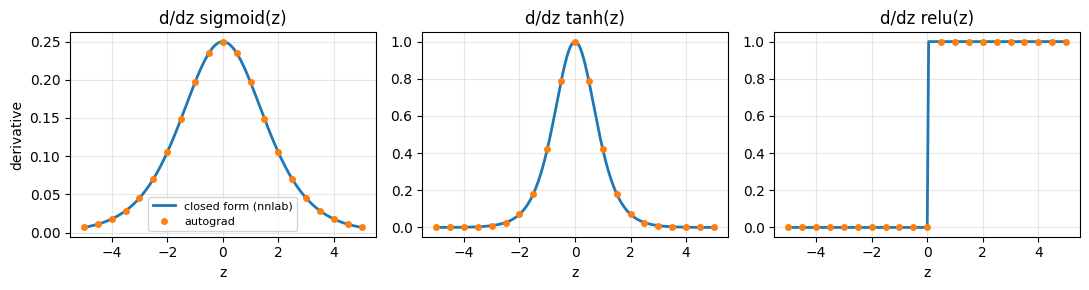

In [16]:
z_grid = np.linspace(-5, 5, 201)                   # z_grid: (201,)
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, (name, fn, d_np) in zip(axes, [("sigmoid", torch.sigmoid, d_sigmoid), ("tanh", torch.tanh, d_tanh), ("relu", torch.relu, d_relu)]):
    z = torch.tensor(z_grid, requires_grad=True)
    fn(z).sum().backward()
    ax.plot(z_grid, d_np(z_grid), lw=2, label="closed form (nnlab)")
    ax.plot(z_grid[::10], z.grad.numpy()[::10], "o", ms=4, label="autograd")
    ax.set_title(f"d/dz {name}(z)"); ax.set_xlabel("z"); ax.grid(alpha=0.3)
axes[0].set_ylabel("derivative"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## ขั้นที่ 7 · `.grad` สะสม และ `torch.no_grad()`
สองพฤติกรรมของ autograd ที่ทำให้คนเขียน training loop ครั้งแรกงง
1. **`.grad` สะสม (accumulate)** — เรียก `backward()` ครั้งที่สอง torch จะ **บวก** gradient ใหม่เข้ากับของเดิม ไม่ได้เขียนทับ
   (ออกแบบไว้ให้รวม gradient จากหลาย mini-batch ได้) ดังนั้นก่อนคำนวณรอบใหม่ต้องล้างด้วย `.grad.zero_()` — ใน lab06 จะเห็นเป็น `optimizer.zero_grad()`
2. **`torch.no_grad()`** — ปิดการจด graph ชั่วคราว ใช้ตอนทำนาย/ประเมินผล (ไม่ต้องการอนุพันธ์) ประหยัดหน่วยความจำและเร็วขึ้น และใช้ตอน update weight ด้วยมือ

นอกจากนี้ tensor ที่มี `requires_grad` เรียก `.numpy()` ตรงๆ ไม่ได้ ต้อง `.detach()` (ตัดออกจาก graph) ก่อน
คาดว่า: backward รอบสอง `a.grad` เป็น 6 (= 3 + 3) → หลัง `zero_()` แล้ว backward ใหม่กลับเป็น 3 → ใน `no_grad` ผลลัพธ์ไม่มี `grad_fn`

In [17]:
# 1) .grad สะสม
print("a.grad ตอนนี้ =", a.grad.item(), "(จาก backward รอบแรก)")
J = 3 * (a + b * c)
J.backward()
print("backward รอบ 2 โดยไม่ล้าง → a.grad =", a.grad.item(), " ← 3 + 3 สะสม ไม่ใช่ 3!")

a.grad.zero_(); b.grad.zero_(); c.grad.zero_()     # ล้างเป็น 0 (ขีดล่างท้ายชื่อ = แก้ในที่)
J = 3 * (a + b * c)
J.backward()
print("ล้างแล้ว backward ใหม่ → a.grad =", a.grad.item(), "b.grad =", b.grad.item(), "c.grad =", c.grad.item(), " ✓")

# 2) torch.no_grad()
print("\nปกติ      : J.requires_grad =", J.requires_grad, "| grad_fn =", J.grad_fn.name())
with torch.no_grad():
    J_eval = 3 * (a + b * c)
print("ใน no_grad: J.requires_grad =", J_eval.requires_grad, "| grad_fn =", J_eval.grad_fn, "| ค่า =", J_eval.item())

# 3) .detach() ก่อน .numpy()
try:
    J.numpy()
except RuntimeError as e:
    print("\nJ.numpy() → RuntimeError:", str(e)[:60], "...")
print("J.detach().numpy() =", J.detach().numpy())

a.grad ตอนนี้ = 3.0 (จาก backward รอบแรก)
backward รอบ 2 โดยไม่ล้าง → a.grad = 6.0  ← 3 + 3 สะสม ไม่ใช่ 3!
ล้างแล้ว backward ใหม่ → a.grad = 3.0 b.grad = 6.0 c.grad = 9.0  ✓

ปกติ      : J.requires_grad = True | grad_fn = MulBackward0
ใน no_grad: J.requires_grad = False | grad_fn = None | ค่า = 33.0

J.numpy() → RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor. ...
J.detach().numpy() = 33.0


## ขั้นที่ 8 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/utils.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (`set_seed` และ `get_device`) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/utils.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

In [18]:
from nnlab.utils import set_seed, get_device
from nnlab.activations import sigmoid

print("get_device() →", get_device())

# set_seed ตั้ง seed ให้ทั้ง numpy และ torch: สุ่มสองครั้งหลัง set_seed เดิมต้องได้ค่าเดียวกัน
set_seed(463); r1 = torch.rand(3)
set_seed(463); r2 = torch.rand(3)
assert torch.equal(r1, r2)
print("torch.rand หลัง set_seed(463) ซ้ำ:", r1, "== ", r2, "✓")
rng = set_seed(463)                                # reset rng ของ notebook ให้ตัวเลขด้านล่างทำซ้ำได้

# งานเดียวกันสองโลก: A = sigmoid(W @ X + b) ใน convention สไลด์
X_np = rng.standard_normal((3, 5))                 # X_np: (n_x, m) = (3, 5)
W_np = rng.standard_normal((1, 3))                 # W_np: (1, n_x)
b_np = 0.1
A_np = sigmoid(W_np @ X_np + b_np)                 # A_np: (1, m) — nnlab (numpy float64)

X_t = torch.tensor(X_np, dtype=torch.float32, device=device)   # float32 บน device ที่มี
W_t = torch.tensor(W_np, dtype=torch.float32, device=device)
A_t = torch.sigmoid(W_t @ X_t + b_np)              # A_t: (1, m) — torch
print("A_np =", A_np.round(4))
print("A_t  =", A_t.cpu().numpy().round(4), "| device", A_t.device, "| dtype", A_t.dtype)
assert np.allclose(A_np, A_t.cpu().numpy(), atol=1e-6)
print("numpy (float64) กับ torch (float32 บน", str(device) + ") ตรงกันภายใน 1e-6 ✓")

get_device() → mps


torch.rand หลัง set_seed(463) ซ้ำ: tensor([0.0532, 0.5757, 0.7595]) ==  tensor([0.0532, 0.5757, 0.7595]) ✓


A_np = [[0.512  0.9489 0.5126 0.4597 0.5856]]


A_t  = [[0.512  0.9489 0.5126 0.4597 0.5856]] | device mps:0 | dtype torch.float32
numpy (float64) กับ torch (float32 บน mps) ตรงกันภายใน 1e-6 ✓


## ★ Key Takeaways
- `torch.Tensor` = `ndarray` + autograd + device; คำสั่งเกือบทั้งหมดชื่อเดียวกัน ต่างแค่ `axis`→`dim`, `keepdims`→`keepdim`, `astype`→`.to`/`.float()`
- torch ใช้ **float32** เป็นค่าเริ่มต้น numpy ใช้ float64; `torch.tensor(ndarray)` รักษา float64 ไว้ และ torch ไม่ยอมคูณสอง dtype ต่างกัน — แก้ด้วย `.float()` แล้วเทียบด้วย `np.allclose(atol=1e-6)`
- `torch.from_numpy` และ `.numpy()` **ใช้หน่วยความจำร่วมกัน** (แก้ตัวหนึ่งอีกตัวเปลี่ยน) ส่วน `torch.tensor(a)` copy; `.numpy()` ต้องอยู่บน cpu และไม่มี requires_grad (`.detach().cpu().numpy()`)
- `get_device()` เลือก cuda > mps > cpu ให้อัตโนมัติ; tensor ต้องอยู่ device เดียวกันจึงคำนวณด้วยกันได้ และ mps ไม่รองรับ float64
- autograd = chain rule ของ lab02 ที่ทำให้อัตโนมัติ: `requires_grad=True` → forward → `J.backward()` → อ่าน `.grad` ได้ 3, 6, 9 ในครั้งเดียว ขณะที่ nudge ต้อง forward ซ้ำตัวแปรละครั้ง
- `.grad` **สะสม** ทุก `backward()` ต้อง `zero_()` (หรือ `optimizer.zero_grad()`) ก่อนรอบใหม่; ใช้ `torch.no_grad()` ตอนทำนาย/ประเมินผลเพื่อไม่สร้าง graph

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [19]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 4.1 · autograd บน graph ที่ตัวแปรโผล่สองที่
**เป้าหมาย:** ใช้ autograd หา $dJ/da, dJ/db, dJ/dc$ ของ $J = (a + b)(b - c)$ แล้วยืนยันด้วยการ nudge (ตัวแปร $b$ โผล่สองที่ อนุพันธ์จึงเป็นผลบวกของสองเส้นทาง)

**ขั้นตอน**
1. สร้าง tensor `a, b, c` จากค่าที่รับเข้ามาด้วย `torch.tensor(float(x), requires_grad=True)`
2. คำนวณ `J = (a + b) * (b - c)` แล้วเรียก `J.backward()`
3. คืน `(a.grad.item(), b.grad.item(), c.grad.item())` เป็น float 3 ตัว

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `torch.tensor(5.0, requires_grad=True)` — ค่าต้องเป็น float ไม่ใช่ int
- `.item()` แปลง tensor 0 มิติเป็น float ของ Python
</details>

In [20]:
# --- แบบฝึกหัด 4.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def grads_autograd(a0, b0, c0):
    """คืน (dJ/da, dJ/db, dJ/dc) ของ J = (a + b)(b - c) ที่จุด (a0, b0, c0) ด้วย autograd"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# grads_autograd(5.0, 3.0, 2.0)   # คาดว่าได้ 3 ตัวเลข

In [21]:
# --- ตรวจคำตอบ 4.1 (รันได้ทันที ไม่ต้องแก้) ---
# อ้างอิงด้วยการ nudge (central difference) — คนละวิธีกับ autograd
def _J(a, b, c): return (a + b) * (b - c)
def _nudge(i, d=1e-5):
    p = np.array([5.0, 3.0, 2.0]); q = p.copy(); p[i] += d; q[i] -= d
    return (_J(*p) - _J(*q)) / (2 * d)
ref = [_nudge(i) for i in range(3)]
check("4.1 คืน 3 ค่า", lambda: len(grads_autograd(5.0, 3.0, 2.0)) == 3, hint="return a.grad.item(), b.grad.item(), c.grad.item()")
check_close("4.1 gradient ตรงกับการ nudge", lambda: grads_autograd(5.0, 3.0, 2.0), ref, atol=1e-4, hint="ต้องเรียก J.backward() ก่อนอ่าน .grad และ tensor ทุกตัวต้อง requires_grad=True")
check_close("4.1 dJ/db = (b-c) + (a+b) รวมสองเส้นทาง", lambda: grads_autograd(5.0, 3.0, 2.0)[1], (3.0 - 2.0) + (5.0 + 3.0), hint="autograd บวก gradient จากทุกเส้นทางที่ b ปรากฏให้เอง")

⏳ 4.1 คืน 3 ค่า: ยังไม่ได้ทำ
⏳ 4.1 gradient ตรงกับการ nudge: ยังไม่ได้ทำ
⏳ 4.1 dJ/db = (b-c) + (a+b) รวมสองเส้นทาง: ยังไม่ได้ทำ


False

### แบบฝึกหัด 4.2 · อนุพันธ์ของ sigmoid หลายจุดในครั้งเดียว
**เป้าหมาย:** เขียนฟังก์ชันที่รับ array ของ $z$ แล้วคืน $g'(z)$ ของ sigmoid ทุกจุดด้วย autograd ครั้งเดียว (ไม่วน loop) แล้วเทียบกับสูตร $g(1-g)$

**ขั้นตอน**
1. สร้าง `z = torch.tensor(z_values, dtype=torch.float64, requires_grad=True)` (shape `(n,)`)
2. คำนวณ `g = torch.sigmoid(z)` แล้วเรียก `g.sum().backward()` — เพราะ $g_i$ ขึ้นกับ $z_i$ ตัวเดียว `z.grad[i]` จึงเป็น $g'(z_i)$ พอดี
3. คืน `z.grad.numpy()`

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- ถ้าเรียก `g.backward()` กับ tensor หลายค่าจะ error `grad can be implicitly created only for scalar outputs` → ใช้ `g.sum().backward()`
- `z.grad` เป็น tensor → `.numpy()` ได้เลยเพราะอยู่บน cpu และ z.grad ไม่ requires_grad
</details>

In [22]:
# --- แบบฝึกหัด 4.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def sigmoid_grad_autograd(z_values):
    """z_values: list/array ของ float → numpy array ของ g'(z) แต่ละจุด (shape (n,))"""
    raise NotImplementedError("ยังไม่ได้ทำ")

z_pts = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])
# sigmoid_grad_autograd(z_pts)

In [23]:
# --- ตรวจคำตอบ 4.2 (รันได้ทันที ไม่ต้องแก้) ---
from nnlab.activations import d_sigmoid
check_shape("4.2 shape (5,)", lambda: np.asarray(sigmoid_grad_autograd(z_pts)), (5,), hint="คืน z.grad.numpy() ไม่ใช่ทั้ง tensor g")
check_close("4.2 ตรงกับสูตร g(1-g)", lambda: sigmoid_grad_autograd(z_pts), d_sigmoid(z_pts), atol=1e-6, hint="ต้อง backward จากผลรวม g.sum() ไม่ใช่จาก g ตรงๆ (backward ต้องการ scalar)")
check_close("4.2 ความชันสูงสุดที่ z = 0 คือ 0.25", lambda: float(np.max(sigmoid_grad_autograd(z_pts))), 0.25, atol=1e-6)

⏳ 4.2 shape (5,): ยังไม่ได้ทำ
⏳ 4.2 ตรงกับสูตร g(1-g): ยังไม่ได้ทำ
⏳ 4.2 ความชันสูงสุดที่ z = 0 คือ 0.25: ยังไม่ได้ทำ


False

### แบบฝึกหัด 4.3 · shared memory: from_numpy กับ torch.tensor ต่างกันอย่างไร
**เป้าหมาย:** ทดลองว่า tensor แบบไหนใช้หน่วยความจำร่วมกับ numpy array แล้วคืนคำตอบเป็น boolean 3 ตัว

**ขั้นตอน**
1. สร้าง `a = np.zeros(4)`, `t1 = torch.from_numpy(a)`, `t2 = torch.tensor(a)`
2. แก้ `t1[0] = 1` แล้วดูว่า `a[0]` เปลี่ยนเป็น 1 ไหม → `shared_t1`; แก้ `t2[1] = 2` แล้วดูว่า `a[1]` เปลี่ยนไหม → `shared_t2`
3. สร้าง `t3 = t1.float()` แล้วแก้ `t3[2] = 3` ดูว่า `a[2]` เปลี่ยนไหม → `shared_float` (การแปลง dtype ต้องสร้างข้อมูลใหม่ไหม?)
4. คืน `(shared_t1, shared_t2, shared_float)` เป็น bool ของ Python

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- เทียบค่าใน array หลังแก้ เช่น `shared_t1 = bool(a[0] == 1.0)`
- ถ้า `a` มี dtype float64 อยู่แล้ว `t1.double()` จะยังแชร์ (ไม่ต้องแปลง) แต่ `.float()` แปลงเป็น float32 จึงต้อง copy
</details>

In [24]:
# --- แบบฝึกหัด 4.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def sharing_demo():
    """คืน (shared_t1, shared_t2, shared_float) — True ถ้าการแก้ tensor ทำให้ array a เปลี่ยนตาม"""
    raise NotImplementedError("ยังไม่ได้ทำ")

In [25]:
# --- ตรวจคำตอบ 4.3 (รันได้ทันที ไม่ต้องแก้) ---
check("4.3 คืน tuple ของ bool 3 ตัว", lambda: len(sharing_demo()) == 3 and all(isinstance(v, (bool, np.bool_)) for v in sharing_demo()), hint="ใช้ bool(a[0] == 1) เป็นต้น")
check("4.3 from_numpy แชร์หน่วยความจำ", lambda: sharing_demo()[0] is True or bool(sharing_demo()[0]), hint="from_numpy ไม่ copy — a ต้องเปลี่ยนตาม")
check("4.3 torch.tensor copy", lambda: not sharing_demo()[1], hint="torch.tensor(a) ถ่ายสำเนา a จึงไม่เปลี่ยน")
check("4.3 .float() สร้างข้อมูลใหม่ (dtype ต่างจึงแชร์ไม่ได้)", lambda: not sharing_demo()[2], hint="float64 → float32 ต้องเก็บคนละรูปแบบ torch จึง copy")

⏳ 4.3 คืน tuple ของ bool 3 ตัว: ยังไม่ได้ทำ
⏳ 4.3 from_numpy แชร์หน่วยความจำ: ยังไม่ได้ทำ
⏳ 4.3 torch.tensor copy: ยังไม่ได้ทำ
⏳ 4.3 .float() สร้างข้อมูลใหม่ (dtype ต่างจึงแชร์ไม่ได้): ยังไม่ได้ทำ


False

### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [26]:
summary()

สรุป: PASS 0/10 · FAIL 0 · ยังไม่ได้ทำ 10


{'pass': 0, 'fail': 0, 'todo': 10, 'error': 0}